<h1 style="color:#56B4E9;">Week 7 — Day 2</h1>

<h2 style="color:#0072B2;">Building CNNs & Transfer Learning</h2>

### Melanoma Skin Cancer Classification

Day 1 established the motivation for using a two-dimensional Convolutional Neural Network for dermoscopic skin-lesion images. We examined convolution, feature maps, stride, padding, and parameter sharing, and confirmed that CNNs are more suitable than dense-only networks for preserving spatial image information.

Day 2 moves from individual convolution operations to complete image-classification models. We will first study pooling and build a CNN from scratch. We will then introduce data augmentation to reduce overfitting and finally apply transfer learning using a pre-trained image model.

The experiments will be evaluated using the validation set while keeping the test set untouched until the final evaluation.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Explain how pooling reduces the spatial size of feature maps.
- Build a complete CNN using convolution, pooling, flattening, and dense layers.
- Train a CNN from scratch on the melanoma image dataset.
- Apply data augmentation to improve generalization and reduce overfitting.
- Use transfer learning with a pre-trained image-classification model.
- Compare validation performance and training time across different approaches.
- Identify which approach provides the strongest practical result for the image-classification project.

<h2 style="color:#0072B2;">Day 2 Experimental Plan</h2>

<span style="color:#D55E00;"><b>Problem:</b></span>  
A CNN built from scratch can learn useful image features, but a limited dataset may cause overfitting. The model may also require considerable training time before learning strong visual representations.

<span style="color:#009E73;"><b>Today's Goal:</b></span>  
Build a complete CNN, improve its generalization using data augmentation, and compare it with a pre-trained transfer-learning model.

### Experimental Sequence

1. Create a stratified validation split from the training data.
2. Examine how pooling changes feature-map dimensions.
3. Build and train a CNN from scratch.
4. Add data augmentation and compare validation behavior.
5. Apply transfer learning using a pre-trained MobileNetV2 model.
6. Compare accuracy, validation performance, and training time.
7. Determine which approach should be carried forward to the next stage.

<span style="color:#D55E00;"><b>Evaluation Rule:</b></span>  
The test set will remain untouched during all experiments. It will only be used after selecting the final model.

In [1]:
from pathlib import Path
import random
import time

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    fbeta_score, precision_score, recall_score
)

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    RandomFlip,
    RandomRotation,
    RandomZoom
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Environment prepared successfully.")
print("TensorFlow version:", tf.__version__)

I0000 00:00:1788206370.400885   39653 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788206370.404447   39653 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788206370.910396   39653 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788206373.263022   39653 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Environment prepared successfully.
TensorFlow version: 2.21.0


In [2]:
dataset_path = Path(
    kagglehub.dataset_download(
        "ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant"
    )
)

print("Dataset path:")
print(dataset_path)

Dataset path:
/home/haitham/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1


In [3]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []

for image_path in dataset_path.rglob("*"):
    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in image_extensions:
        continue

    path_parts = [part.lower() for part in image_path.parts]

    label = next(
        (
            class_name
            for class_name in ["benign", "malignant"]
            if class_name in path_parts
        ),
        None
    )

    split = next(
        (
            split_name
            for split_name in ["train", "validation", "valid", "val", "test"]
            if split_name in path_parts
        ),
        "unspecified"
    )

    if label is not None:
        records.append({
            "path": image_path,
            "split": split,
            "label": label
        })

image_data = pd.DataFrame(records)

print("Detected images:", len(image_data))
display(image_data.head())

Detected images: 13879


,path,split,label
0,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
1,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
2,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
3,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign
4,/home/haitham/.cache/kagglehub/datasets/ailear...,test,benign


<h2 style="color:#0072B2;">Validation Split Preparation</h2>

The dataset inspected on Day 1 contains separate training and test sets but no dedicated validation set.

A validation subset will therefore be created from the training images. Stratification will preserve approximately the same benign-to-malignant class ratio in both subsets.

The test set remains completely untouched.

We will use `20%` of the original training data for validation.

In [4]:
train_data = image_data[
    image_data["split"] == "train"
].copy()

test_data = image_data[
    image_data["split"] == "test"
].copy()

train_data, validation_data = train_test_split(
    train_data,
    test_size=0.20,
    random_state=SEED,
    stratify=train_data["label"]
)

train_data = train_data.reset_index(drop=True)
validation_data = validation_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

validation_distribution = pd.crosstab(
    validation_data["label"],
    columns="Count"
)

split_summary = pd.DataFrame([
    {
        "Split": "Training",
        "Images": len(train_data),
        "Benign": (train_data["label"] == "benign").sum(),
        "Malignant": (train_data["label"] == "malignant").sum()
    },
    {
        "Split": "Validation",
        "Images": len(validation_data),
        "Benign": (validation_data["label"] == "benign").sum(),
        "Malignant": (validation_data["label"] == "malignant").sum()
    },
    {
        "Split": "Test",
        "Images": len(test_data),
        "Benign": (test_data["label"] == "benign").sum(),
        "Malignant": (test_data["label"] == "malignant").sum()
    }
])

display(split_summary)

,Split,Images,Benign,Malignant
0,Training,9503,5031,4472
1,Validation,2376,1258,1118
2,Test,2000,1000,1000


<h2 style="color:#0072B2;">2.1 Pooling</h2>

Pooling is used in CNNs to reduce the spatial dimensions of feature maps while preserving the most important information.

One of the most common pooling operations is <b>Max Pooling</b>. It divides a feature map into small regions and keeps only the maximum value from each region.

This reduces the number of spatial values that subsequent layers need to process and makes the network less sensitive to small changes in the exact location of detected features.

In this experiment, we will visualize the effect of Max Pooling on a feature map.

In [5]:
feature_map = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
], dtype=np.float32)

pooling_layer = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

input_map = tf.constant(
    feature_map.reshape(1, 4, 4, 1)
)

pooled_map = pooling_layer(input_map)

print("Original feature map:")
print(feature_map)

print("\nPooled feature map:")
print(pooled_map.numpy().squeeze())

Original feature map:
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

Pooled feature map:
[[ 6.  8.]
 [14. 16.]]


E0000 00:00:1788206374.643431   39653 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<h3 style="color:#009E73;">Pooling Result</h3>

The original feature map has a spatial size of <b>4 × 4</b>. After applying a `2 × 2` Max Pooling operation with a stride of `2`, the spatial dimensions are reduced to <b>2 × 2</b>.

For each `2 × 2` region, only the largest value is retained:

- Top-left region → `6`
- Top-right region → `8`
- Bottom-left region → `14`
- Bottom-right region → `16`

This demonstrates how pooling reduces the spatial size of feature maps while keeping the strongest detected responses.

<h2 style="color:#0072B2;">Pooling on a Real Melanoma Image</h2>

After observing Max Pooling on a simple numerical feature map, we will now apply the same operation to an actual melanoma image from the dataset.

The image will first be resized to a fixed resolution and normalized. A `2 × 2` Max Pooling layer with a stride of `2` will then be applied independently to the spatial dimensions.

The purpose of this experiment is to visualize how pooling reduces the spatial resolution of a real image while retaining the strongest local responses.

In [6]:
sample_path = train_data.iloc[0]["path"]
sample_label = train_data.iloc[0]["label"]

image = Image.open(sample_path).convert("RGB")
image = image.resize((128, 128))

image_array = np.array(image).astype("float32") / 255.0

pooling_layer = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding="valid"
)

image_tensor = tf.expand_dims(image_array, axis=0)

pooled_image = pooling_layer(image_tensor)

pooled_image = pooled_image.numpy().squeeze()

print("Label:", sample_label)
print("Original image shape:", image_array.shape)
print("Pooled image shape:", pooled_image.shape)

Label: benign
Original image shape: (128, 128, 3)
Pooled image shape: (64, 64, 3)


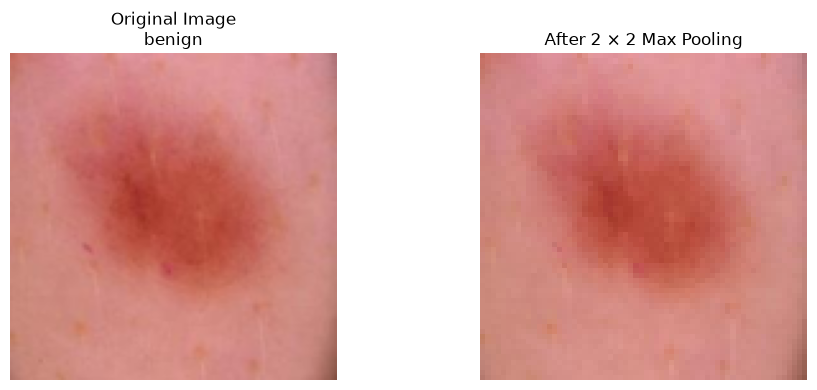

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title(f"Original Image\n{sample_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(pooled_image, 0, 1))
plt.title("After 2 × 2 Max Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Real Image Pooling Result</h3>

The original image has a spatial resolution of `128 × 128` pixels. After applying `2 × 2` Max Pooling with a stride of `2`, the spatial resolution becomes `64 × 64`.

The number of channels remains unchanged because the pooling operation is performed independently across the spatial dimensions for each channel.

<span style="color:#D55E00;"><b>Observation:</b></span>

Pooling significantly reduces the spatial size of the image representation. This reduces the amount of information that subsequent CNN layers need to process while retaining strong local responses.

In a complete CNN, pooling is normally applied to learned feature maps produced by convolutional layers rather than directly to the original image. This experiment is mainly a visual demonstration of the spatial downsampling effect.

<h2 style="color:#0072B2;">2.2 Building a Full CNN</h2>

Now that the effect of pooling is clear, we can combine convolution and pooling layers into a complete CNN architecture.

The model will progressively learn visual features from the melanoma images:

- Early convolutional layers will learn simple patterns such as edges and textures.
- Deeper convolutional layers will learn more complex visual patterns.
- Max Pooling will reduce the spatial dimensions of the feature maps.
- Flattening will convert the learned feature maps into a one-dimensional representation.
- Dense layers will use these learned features to perform the final binary classification.

This model will be trained from scratch without using any pre-trained weights.

In [8]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    
    label = tf.cast(label, tf.float32)
    
    return image, label

In [9]:
label_map = {
    "benign": 0,
    "malignant": 1
}

train_paths = train_data["path"].astype(str).values
train_labels = train_data["label"].map(label_map).values

validation_paths = validation_data["path"].astype(str).values
validation_labels = validation_data["label"].map(label_map).values

test_paths = test_data["path"].astype(str).values
test_labels = test_data["label"].map(label_map).values

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

validation_dataset = tf.data.Dataset.from_tensor_slices(
    (validation_paths, validation_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

train_dataset = (
    train_dataset
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(len(train_data), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

validation_dataset = (
    validation_dataset
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Training batches: 297
Validation batches: 75
Test batches: 63


<h3 style="color:#009E73;">Input Pipeline</h3>

The images are resized to `128 × 128` pixels and normalized to the range `[0, 1]`.

The datasets are then batched and prefetched to make the training process more efficient.

The labels are encoded as:

- `0` → Benign
- `1` → Malignant

The same preprocessing is applied to the training, validation, and test sets.

<h3 style="color:#0072B2;">CNN Architecture</h3>

The first CNN will contain three convolutional blocks.

Each block consists of:

1. A convolutional layer to extract visual features.
2. A Max Pooling layer to reduce the spatial dimensions.

After the convolutional blocks, the feature maps will be flattened and passed through dense layers for binary classification.

The model will use a sigmoid output because this is a two-class classification problem.

In [10]:
cnn_model = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

<h3 style="color:#009E73;">Model Design</h3>

The CNN progressively increases the number of filters from `32` to `64` and then `128`.

At the same time, Max Pooling reduces the spatial dimensions of the feature maps after each convolutional block.

This creates a common CNN pattern:

<b>Convolution → Pooling → Convolution → Pooling → Convolution → Pooling → Classification</b>

The final sigmoid neuron produces a value between `0` and `1`, representing the predicted probability of the malignant class.

<h2 style="color:#0072B2;">2.3 Training the CNN from Scratch</h2>

The CNN architecture is now ready for training.

The model will be trained on the training dataset and evaluated after each epoch using the validation dataset.

The test dataset will remain untouched during this experiment.

In [11]:
def make_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=3,
            restore_best_weights=True
        )
    ]

print("Early stopping will restore the weights with the lowest validation loss.")

Early stopping will restore the weights with the lowest validation loss.


In [12]:
EPOCHS = 15

start_time = time.time()

cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks()
)

cnn_training_time = time.time() - start_time

print(
    f"\nCNN training time: "
    f"{cnn_training_time / 60:.2f} minutes"
)

Epoch 1/15


/home/haitham/binx-ai-ml-internship/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


297/297 ━━━━━━━━━━━━━━━━━━━━ 70s 216ms/step - accuracy: 0.7556 - loss: 0.4925 - val_accuracy: 0.7778 - val_loss: 0.4500
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - accuracy: 0.8283 - loss: 0.3895 - val_accuracy: 0.8565 - val_loss: 0.3507
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 60s 183ms/step - accuracy: 0.8420 - loss: 0.3558 - val_accuracy: 0.8468 - val_loss: 0.3521
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 75s 247ms/step - accuracy: 0.8550 - loss: 0.3340 - val_accuracy: 0.8540 - val_loss: 0.3416
Epoch 5/15


I0000 00:00:1788206649.061689   40478 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 8108 of 9503
I0000 00:00:1788206655.784713   40478 shuffle_dataset_op.cc:483] Shuffle buffer filled.


297/297 ━━━━━━━━━━━━━━━━━━━━ 128s 373ms/step - accuracy: 0.8555 - loss: 0.3264 - val_accuracy: 0.8152 - val_loss: 0.4059
Epoch 6/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 109s 351ms/step - accuracy: 0.8633 - loss: 0.3140 - val_accuracy: 0.8607 - val_loss: 0.3318
Epoch 7/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 101s 324ms/step - accuracy: 0.8690 - loss: 0.3000 - val_accuracy: 0.8645 - val_loss: 0.3208
Epoch 8/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 104s 320ms/step - accuracy: 0.8773 - loss: 0.2902 - val_accuracy: 0.8540 - val_loss: 0.3556
Epoch 9/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 106s 336ms/step - accuracy: 0.8821 - loss: 0.2683 - val_accuracy: 0.8737 - val_loss: 0.3067
Epoch 10/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 114s 353ms/step - accuracy: 0.8831 - loss: 0.2666 - val_accuracy: 0.8645 - val_loss: 0.3074
Epoch 11/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 108s 353ms/step - accuracy: 0.8896 - loss: 0.2535 - val_accuracy: 0.8712 - val_loss: 0.3176
Epoch 12/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 110s 350ms/step - accuracy: 0.8963 - loss: 0

I0000 00:00:1788207528.000358   41576 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 9392 of 9503
I0000 00:00:1788207528.210971   41576 shuffle_dataset_op.cc:483] Shuffle buffer filled.


297/297 ━━━━━━━━━━━━━━━━━━━━ 108s 328ms/step - accuracy: 0.9000 - loss: 0.2337 - val_accuracy: 0.8775 - val_loss: 0.3145
Epoch 14/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 87s 271ms/step - accuracy: 0.9051 - loss: 0.2286 - val_accuracy: 0.8687 - val_loss: 0.3524
Epoch 15/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 65s 214ms/step - accuracy: 0.9095 - loss: 0.2139 - val_accuracy: 0.8683 - val_loss: 0.3192

CNN training time: 23.37 minutes


<h3 style="color:#009E73;">Run-Dependent Result</h3>

The exact values are generated by the executed code cells. Because early stopping restores the best validation-loss weights, interpretation must use the new comparison table rather than numbers from the earlier ten-epoch run.

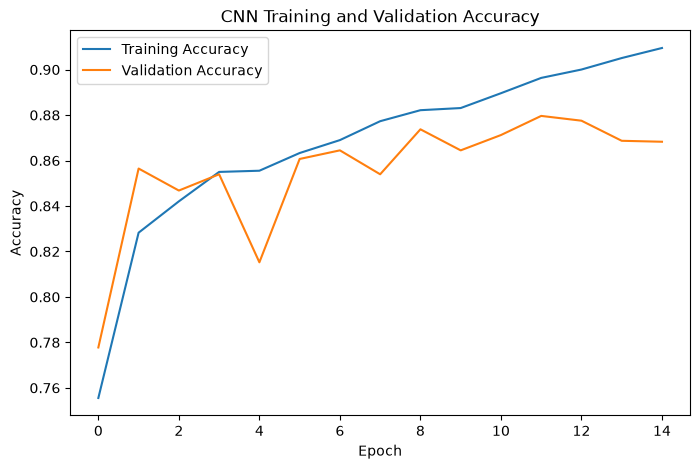

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")

plt.legend()
plt.show()

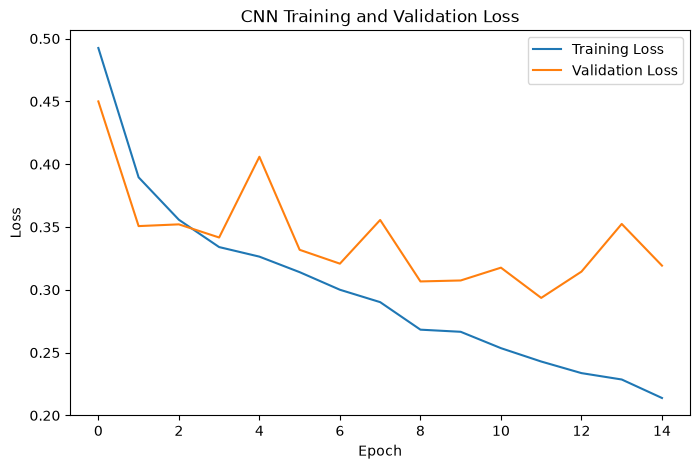

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")

plt.legend()
plt.show()

In [15]:
cnn_best_val_accuracy = max(
    cnn_history.history["val_accuracy"]
)

cnn_best_val_loss = min(
    cnn_history.history["val_loss"]
)

print("CNN from Scratch Results")
print(
    f"Best Validation Accuracy: "
    f"{cnn_best_val_accuracy:.4f}"
)

print(
    f"Best Validation Loss: "
    f"{cnn_best_val_loss:.4f}"
)

print(
    f"Training Time: "
    f"{cnn_training_time / 60:.2f} minutes"
)

CNN from Scratch Results
Best Validation Accuracy: 0.8796
Best Validation Loss: 0.2935
Training Time: 23.37 minutes


<h2 style="color:#0072B2;">2.4 Data Augmentation</h2>

The CNN trained from scratch achieved good validation performance, but the training data can still be expanded artificially during training.

Data augmentation creates modified versions of training images.

In this experiment, the following transformations will be applied:

- Horizontal flipping.
- Small rotations.
- Small zoom operations.

The purpose is to increase training-image diversity and improve model generalization.

The validation and test datasets remain unchanged.

In [16]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

data_augmentation

<Sequential name=sequential_1, built=False>

<h3 style="color:#009E73;">CNN with Data Augmentation</h3>

A new CNN will be trained using the same architecture as the original CNN.

The difference is that data augmentation is applied to the training images before they pass through the convolutional layers.

This allows a fair comparison between the original CNN and the augmented CNN.

In [17]:
augmented_cnn_model = Sequential([
    Input(shape=(128, 128, 3)),
    data_augmentation,

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

augmented_cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

augmented_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

<h3 style="color:#009E73;">Training CNN with Data Augmentation</h3>

The CNN architecture remains the same.

The difference is that augmented versions of the training images will be generated during training.

The validation dataset remains unchanged so that the results can be compared fairly with the original CNN.

In [18]:
start_time = time.time()

augmented_cnn_history = augmented_cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks()
)

augmented_cnn_training_time = time.time() - start_time

print(
    f"\nAugmented CNN training time: "
    f"{augmented_cnn_training_time / 60:.2f} minutes"
)

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 77s 244ms/step - accuracy: 0.7420 - loss: 0.5115 - val_accuracy: 0.8316 - val_loss: 0.3973
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 79s 246ms/step - accuracy: 0.8216 - loss: 0.4024 - val_accuracy: 0.8430 - val_loss: 0.3667
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 112s 370ms/step - accuracy: 0.8301 - loss: 0.3813 - val_accuracy: 0.8333 - val_loss: 0.3847
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 110s 347ms/step - accuracy: 0.8418 - loss: 0.3585 - val_accuracy: 0.8359 - val_loss: 0.3734
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 126s 397ms/step - accuracy: 0.8466 - loss: 0.3530 - val_accuracy: 0.8447 - val_loss: 0.3687

Augmented CNN training time: 8.39 minutes


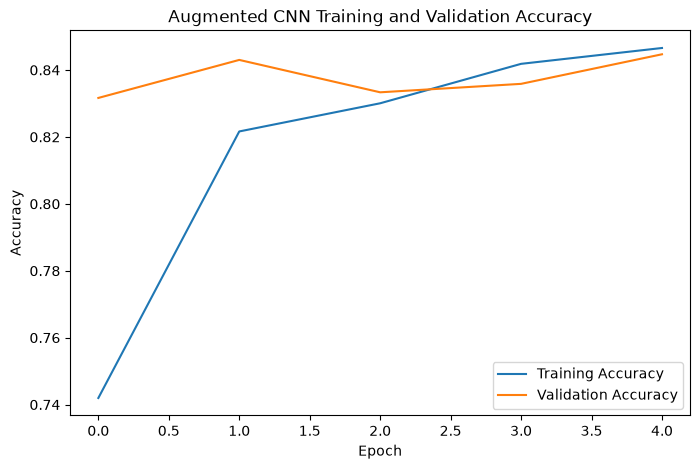

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    augmented_cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    augmented_cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Augmented CNN Training and Validation Accuracy"
)

plt.legend()
plt.show()

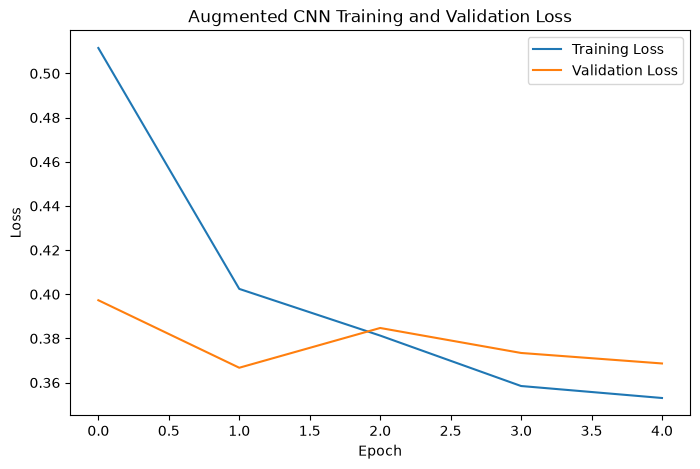

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    augmented_cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    augmented_cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Augmented CNN Training and Validation Loss"
)

plt.legend()
plt.show()

In [21]:
augmented_cnn_best_val_accuracy = max(
    augmented_cnn_history.history["val_accuracy"]
)

augmented_cnn_best_val_loss = min(
    augmented_cnn_history.history["val_loss"]
)

print("CNN with Data Augmentation Results")
print(
    f"Best Validation Accuracy: "
    f"{augmented_cnn_best_val_accuracy:.4f}"
)
print(
    f"Best Validation Loss: "
    f"{augmented_cnn_best_val_loss:.4f}"
)
print(
    f"Training Time: "
    f"{augmented_cnn_training_time / 60:.2f} minutes"
)

CNN with Data Augmentation Results
Best Validation Accuracy: 0.8447
Best Validation Loss: 0.3667
Training Time: 8.39 minutes


<h3 style="color:#009E73;">Run-Dependent Result</h3>

The exact values are generated by the executed code cells. Because early stopping restores the best validation-loss weights, interpretation must use the new comparison table rather than numbers from the earlier ten-epoch run.

<h2 style="color:#0072B2;">2.5 Transfer Learning with MobileNetV2</h2>

The previous models learned their visual features directly from the available melanoma dataset.

Transfer learning takes a different approach.

A pre-trained image model already contains learned visual representations from a large image dataset. These learned features can be reused for a new classification problem.

In this experiment, MobileNetV2 will be used as a frozen feature extractor.

In [22]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print(
    "Number of layers in MobileNetV2:",
    len(base_model.layers)
)

Number of layers in MobileNetV2: 154


<h3 style="color:#009E73;">Frozen Feature Extractor</h3>

The MobileNetV2 model contains `154` layers.

Its pre-trained parameters are frozen, meaning that they will not be updated during training.

A new classification layer will be trained on top of the pre-trained feature extractor.

The input images are also rescaled to the range expected by MobileNetV2.

In [23]:
transfer_model = Sequential([
    tf.keras.layers.Rescaling(
        2.0,
        offset=-1.0,
        input_shape=(128, 128, 3)
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    Dense(
        1,
        activation="sigmoid"
    )
])

transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

/home/haitham/binx-ai-ml-internship/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
start_time = time.time()

transfer_history = transfer_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks()
)

transfer_training_time = time.time() - start_time

print(
    f"\nTransfer Learning training time: "
    f"{transfer_training_time / 60:.2f} minutes"
)

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 111s 337ms/step - accuracy: 0.8255 - loss: 0.3866 - val_accuracy: 0.8514 - val_loss: 0.3395
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 57s 187ms/step - accuracy: 0.8620 - loss: 0.3104 - val_accuracy: 0.8641 - val_loss: 0.3088
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 92s 296ms/step - accuracy: 0.8743 - loss: 0.2901 - val_accuracy: 0.8729 - val_loss: 0.2965
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 109s 358ms/step - accuracy: 0.8807 - loss: 0.2757 - val_accuracy: 0.8712 - val_loss: 0.3012
Epoch 5/15


I0000 00:00:1788208666.888414   43097 shuffle_dataset_op.cc:453] ShuffleDatasetV3:4: Filling up shuffle buffer (this may take a while): 8130 of 9503
I0000 00:00:1788208678.155793   43097 shuffle_dataset_op.cc:483] Shuffle buffer filled.


297/297 ━━━━━━━━━━━━━━━━━━━━ 120s 330ms/step - accuracy: 0.8850 - loss: 0.2664 - val_accuracy: 0.8758 - val_loss: 0.2904
Epoch 6/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 109s 340ms/step - accuracy: 0.8920 - loss: 0.2595 - val_accuracy: 0.8763 - val_loss: 0.2917
Epoch 7/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 103s 321ms/step - accuracy: 0.8911 - loss: 0.2562 - val_accuracy: 0.8708 - val_loss: 0.3023
Epoch 8/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 103s 328ms/step - accuracy: 0.8932 - loss: 0.2497 - val_accuracy: 0.8809 - val_loss: 0.2896
Epoch 9/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 102s 335ms/step - accuracy: 0.8989 - loss: 0.2441 - val_accuracy: 0.8796 - val_loss: 0.2892
Epoch 10/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 103s 337ms/step - accuracy: 0.8982 - loss: 0.2413 - val_accuracy: 0.8767 - val_loss: 0.2859
Epoch 11/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 104s 322ms/step - accuracy: 0.8997 - loss: 0.2396 - val_accuracy: 0.8754 - val_loss: 0.2913
Epoch 12/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 101s 321ms/step - accuracy: 0.9025 - loss: 0

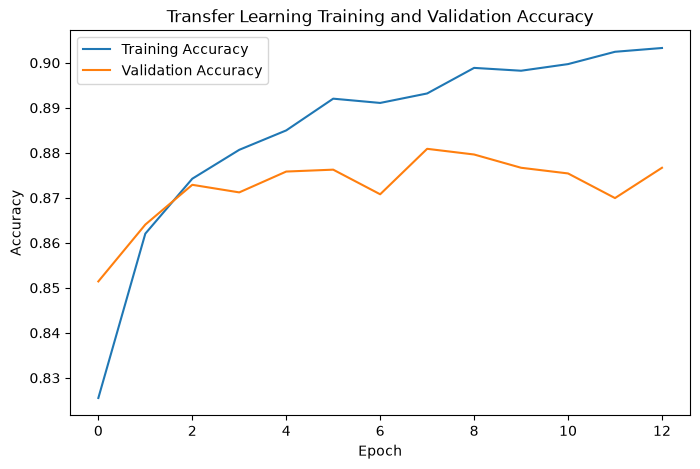

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    transfer_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    transfer_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Transfer Learning Training and Validation Accuracy"
)

plt.legend()
plt.show()

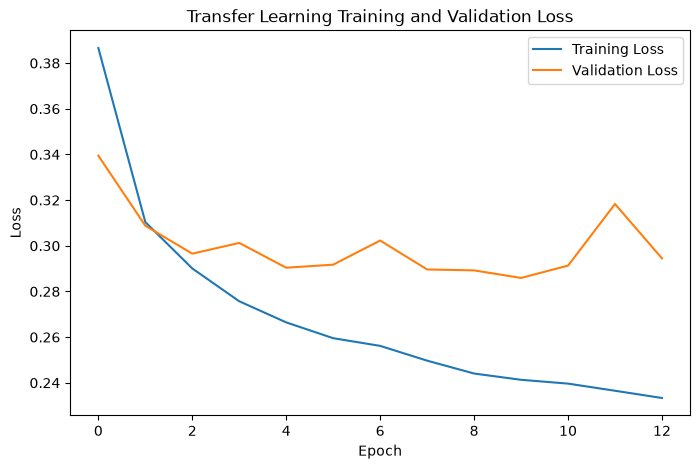

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    transfer_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    transfer_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Transfer Learning Training and Validation Loss"
)

plt.legend()
plt.show()

In [27]:
transfer_best_val_accuracy = max(
    transfer_history.history["val_accuracy"]
)

transfer_best_val_loss = min(
    transfer_history.history["val_loss"]
)

print("Transfer Learning Results")
print(
    f"Best Validation Accuracy: "
    f"{transfer_best_val_accuracy:.4f}"
)
print(
    f"Best Validation Loss: "
    f"{transfer_best_val_loss:.4f}"
)
print(
    f"Training Time: "
    f"{transfer_training_time / 60:.2f} minutes"
)

Transfer Learning Results
Best Validation Accuracy: 0.8809
Best Validation Loss: 0.2859
Training Time: 21.91 minutes


<h3 style="color:#009E73;">Run-Dependent Result</h3>

The exact values are generated by the executed code cells. Because early stopping restores the best validation-loss weights, interpretation must use the new comparison table rather than numbers from the earlier ten-epoch run.

<h2 style="color:#0072B2;">2.6 Medical Validation Metrics</h2>

Accuracy alone does not show how many malignant lesions were missed. The positive class is `malignant = 1`, so every model is also evaluated using malignant recall, F1, F2, and a confusion matrix. F2 gives recall more weight than precision.

In [28]:
def evaluate_predictions(model, dataset, true_labels, model_name, training_minutes):
    probabilities = model.predict(dataset, verbose=0).reshape(-1)
    predictions = (probabilities >= 0.50).astype(int)
    loss = model.evaluate(dataset, verbose=0)[0]
    return {
        "Model": model_name,
        "Validation Loss": loss,
        "Accuracy": accuracy_score(true_labels, predictions),
        "Precision": precision_score(true_labels, predictions, zero_division=0),
        "Malignant Recall": recall_score(true_labels, predictions, zero_division=0),
        "F1": f1_score(true_labels, predictions, zero_division=0),
        "F2": fbeta_score(true_labels, predictions, beta=2, zero_division=0),
        "Training Time (minutes)": training_minutes,
    }, confusion_matrix(true_labels, predictions)

cnn_metrics, cnn_cm = evaluate_predictions(
    cnn_model, validation_dataset, validation_labels,
    "CNN from Scratch", cnn_training_time / 60
)
augmented_metrics, augmented_cm = evaluate_predictions(
    augmented_cnn_model, validation_dataset, validation_labels,
    "CNN + Data Augmentation", augmented_cnn_training_time / 60
)
frozen_metrics, frozen_cm = evaluate_predictions(
    transfer_model, validation_dataset, validation_labels,
    "Frozen MobileNetV2", transfer_training_time / 60
)

transfer_model.save_weights("frozen_mobilenet.weights.h5")
display(pd.DataFrame([cnn_metrics, augmented_metrics, frozen_metrics]).round(4))

,Model,Validation Loss,Accuracy,Precision,Malignant Recall,F1,F2,Training Time (minutes)
0,CNN from Scratch,0.2935,0.8796,0.8599,0.8891,0.8742,0.8831,23.3747
1,CNN + Data Augmentation,0.3667,0.8430,0.8248,0.8462,0.8353,0.8418,8.3863
2,Frozen MobileNetV2,0.2859,0.8767,0.8686,0.8694,0.8690,0.8693,21.9102


<h2 style="color:#0072B2;">2.7 Fine-Tuning MobileNetV2</h2>

The frozen phase trained only the new classification head. Fine-tuning now opens the final 30 MobileNetV2 layers so advanced visual features can adapt to dermoscopic images. Earlier layers remain frozen, and the learning rate is reduced to `1e-5` to avoid destroying useful pre-trained features.

In [29]:
base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Trainable MobileNetV2 layers:", sum(layer.trainable for layer in base_model.layers))

Trainable MobileNetV2 layers: 19


In [30]:
FINE_TUNE_EPOCHS = 5
start_time = time.time()

fine_tune_history = transfer_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=make_callbacks()
)

fine_tune_time = time.time() - start_time
fine_tuned_total_time = transfer_training_time + fine_tune_time

fine_tuned_metrics, fine_tuned_cm = evaluate_predictions(
    transfer_model, validation_dataset, validation_labels,
    "Fine-tuned MobileNetV2", fine_tuned_total_time / 60
)

print(f"Fine-tuning time: {fine_tune_time / 60:.2f} minutes")
display(pd.DataFrame([fine_tuned_metrics]).round(4))

Epoch 1/5


/home/haitham/binx-ai-ml-internship/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


297/297 ━━━━━━━━━━━━━━━━━━━━ 144s 401ms/step - accuracy: 0.9008 - loss: 0.2434 - val_accuracy: 0.8767 - val_loss: 0.2976
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 120s 391ms/step - accuracy: 0.9187 - loss: 0.2031 - val_accuracy: 0.8733 - val_loss: 0.3139
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 114s 367ms/step - accuracy: 0.9347 - loss: 0.1705 - val_accuracy: 0.8779 - val_loss: 0.2755
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 114s 374ms/step - accuracy: 0.9450 - loss: 0.1463 - val_accuracy: 0.8855 - val_loss: 0.2896
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 119s 391ms/step - accuracy: 0.9560 - loss: 0.1269 - val_accuracy: 0.8855 - val_loss: 0.2795
Fine-tuning time: 10.20 minutes


,Model,Validation Loss,Accuracy,Precision,Malignant Recall,F1,F2,Training Time (minutes)
0,Fine-tuned MobileNetV2,0.2755,0.8779,0.86,0.8846,0.8721,0.8796,32.113


<h2 style="color:#0072B2;">2.8 Model Comparison</h2>

The winner is selected using validation F2, with malignant recall as the tie-breaker. This preserves the medical priority established on Day 1.

In [31]:
comparison_results = pd.DataFrame([
    cnn_metrics,
    augmented_metrics,
    frozen_metrics,
    fine_tuned_metrics
]).sort_values(["F2", "Malignant Recall"], ascending=False).reset_index(drop=True)

display(comparison_results.round(4))
best_model_name = comparison_results.iloc[0]["Model"]

if best_model_name == "CNN from Scratch":
    best_model = cnn_model
elif best_model_name == "CNN + Data Augmentation":
    best_model = augmented_cnn_model
elif best_model_name == "Frozen MobileNetV2":
    transfer_model.load_weights("frozen_mobilenet.weights.h5")
    best_model = transfer_model
else:
    best_model = transfer_model

print("Selected final model:", best_model_name)
print("Reason: highest validation F2, with malignant recall as tie-breaker.")

,Model,Validation Loss,Accuracy,Precision,Malignant Recall,F1,F2,Training Time (minutes)
0,CNN from Scratch,0.2935,0.8796,0.8599,0.8891,0.8742,0.8831,23.3747
1,Fine-tuned MobileNetV2,0.2755,0.8779,0.8600,0.8846,0.8721,0.8796,32.1130
2,Frozen MobileNetV2,0.2859,0.8767,0.8686,0.8694,0.8690,0.8693,21.9102
3,CNN + Data Augmentation,0.3667,0.8430,0.8248,0.8462,0.8353,0.8418,8.3863


Selected final model: CNN from Scratch
Reason: highest validation F2, with malignant recall as tie-breaker.


<h2 style="color:#0072B2;">2.9 Final Test Evaluation</h2>

Only the selected model is evaluated on the untouched test set. The confusion matrix explicitly reports false negatives: malignant lesions predicted as benign.

,Selected Model,Test Loss,Test Accuracy,Test Precision,Test Malignant Recall,Test F1,Test F2
0,CNN from Scratch,0.2709,0.897,0.9161,0.874,0.8946,0.8821


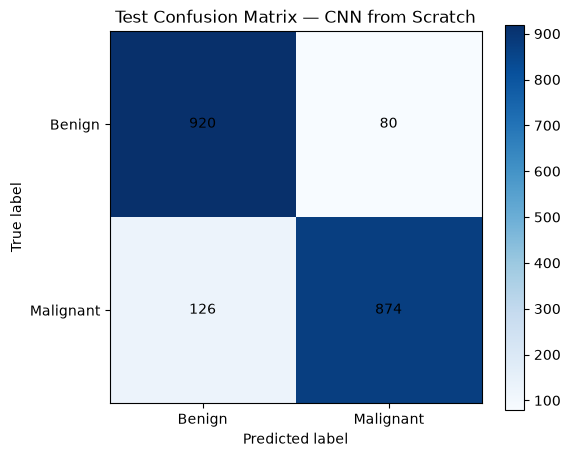

False negatives (missed malignant lesions): 126


In [32]:
test_probabilities = best_model.predict(test_dataset, verbose=0).reshape(-1)
test_predictions = (test_probabilities >= 0.50).astype(int)
test_loss = best_model.evaluate(test_dataset, verbose=0)[0]
test_cm = confusion_matrix(test_labels, test_predictions)

final_test_results = pd.DataFrame([{
    "Selected Model": best_model_name,
    "Test Loss": test_loss,
    "Test Accuracy": accuracy_score(test_labels, test_predictions),
    "Test Precision": precision_score(test_labels, test_predictions, zero_division=0),
    "Test Malignant Recall": recall_score(test_labels, test_predictions, zero_division=0),
    "Test F1": f1_score(test_labels, test_predictions, zero_division=0),
    "Test F2": fbeta_score(test_labels, test_predictions, beta=2, zero_division=0),
}])
display(final_test_results.round(4))

plt.figure(figsize=(6, 5))
plt.imshow(test_cm, cmap="Blues")
plt.title(f"Test Confusion Matrix — {best_model_name}")
plt.xticks([0, 1], ["Benign", "Malignant"])
plt.yticks([0, 1], ["Benign", "Malignant"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
for i in range(2):
    for j in range(2):
        plt.text(j, i, test_cm[i, j], ha="center", va="center")
plt.colorbar(); plt.show()

tn, fp, fn, tp = test_cm.ravel()
print("False negatives (missed malignant lesions):", fn)

<h2 style="color:#0072B2;">Day 2 Conclusion</h2>

This notebook fulfills the complete Day 2 workflow: pooling, a CNN from scratch, data augmentation, frozen transfer learning, fine-tuning, and final comparison. The selected model is determined by validation F2 and malignant recall rather than accuracy alone. The test set is opened only once after model selection, and the final confusion matrix makes missed malignant lesions visible.